In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
data = pd.read_csv("C:/Users/DELL/Downloads/archive (3)/val.csv")

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19823 entries, 0 to 19822
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_id    19823 non-null  int64 
 1   question    19822 non-null  object
 2   answer      19823 non-null  object
 3   image_path  19823 non-null  object
dtypes: int64(1), object(3)
memory usage: 619.6+ KB


In [4]:
data.isna().sum()

image_id      0
question      1
answer        0
image_path    0
dtype: int64

In [5]:
data = data.dropna(subset=['question']) 

In [6]:
print("Unique images:", data['image_id'].nunique())

Unique images: 2411


In [7]:
print("Unique questions:", data['question'].nunique())

Unique questions: 7863


In [8]:
print("Unique answers:", data['answer'].nunique())

Unique answers: 82


In [9]:
print(data['question'].value_counts().head(10))

question
What is the name of the object in the image?    846
Are there any person in image?                  811
How many person in image?                       435
Are there any cup in image?                     249
Are there any bowl in image?                    218
Are there any vase in image?                    168
Are there any fork in image?                    151
Are there any teddy bear in image?              147
Are there any car in image?                     147
Are there any bottle in image?                  145
Name: count, dtype: int64


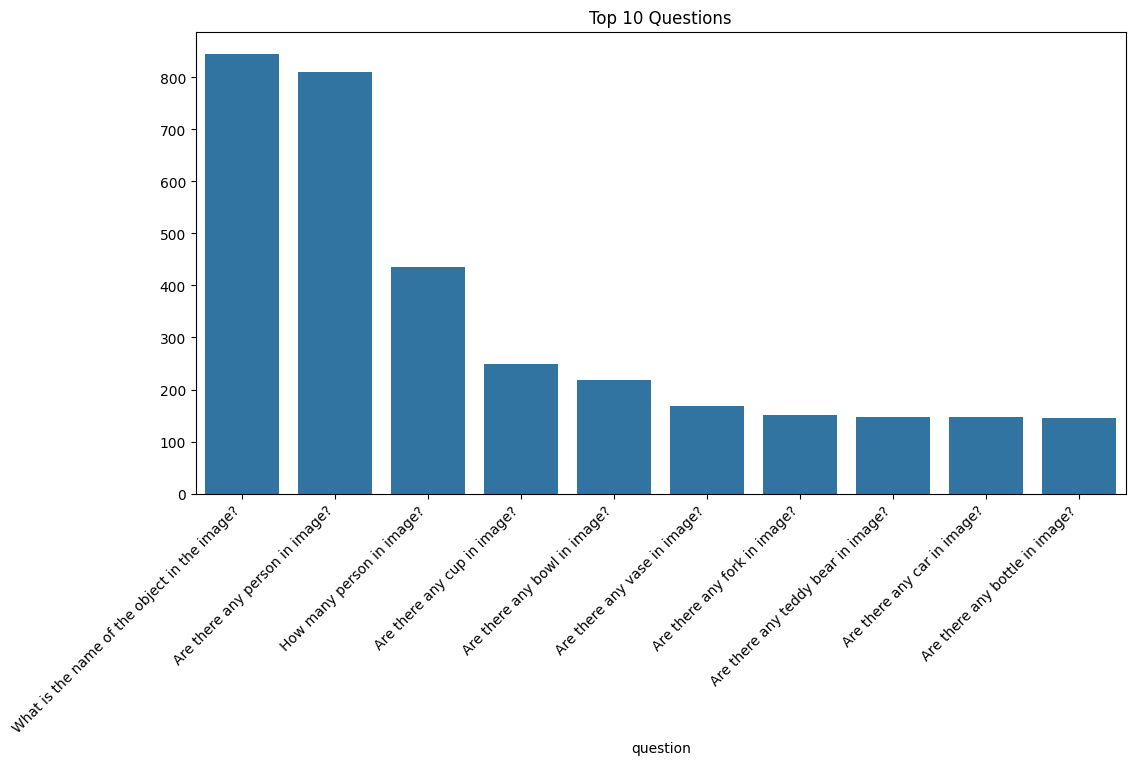

In [10]:
plt.figure(figsize=(12,6))
sns.barplot(x=data['question'].value_counts().head(10).index, y=data['question'].value_counts().head(10).values)
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Questions")
plt.show()


In [11]:
print(data['answer'].value_counts().head(10))

answer
Yes      7568
No       5033
0         534
White     507
1         502
2         458
Black     430
Red       410
Brown     402
Left      379
Name: count, dtype: int64


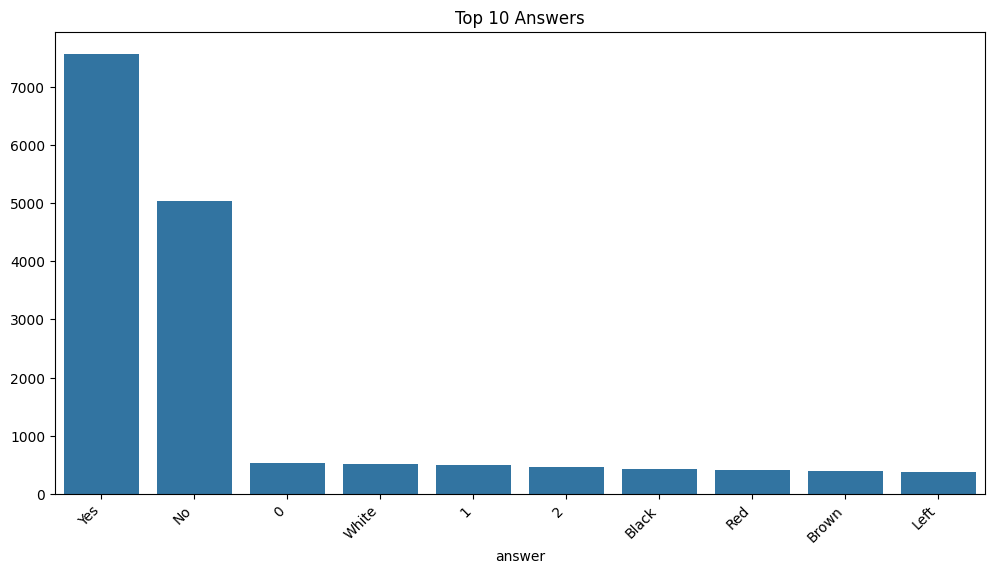

In [35]:
plt.figure(figsize=(12,6))
sns.barplot(x=data['answer'].value_counts().head(10).index, y=data['answer'].value_counts().head(10).values)
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Answers")
plt.show()

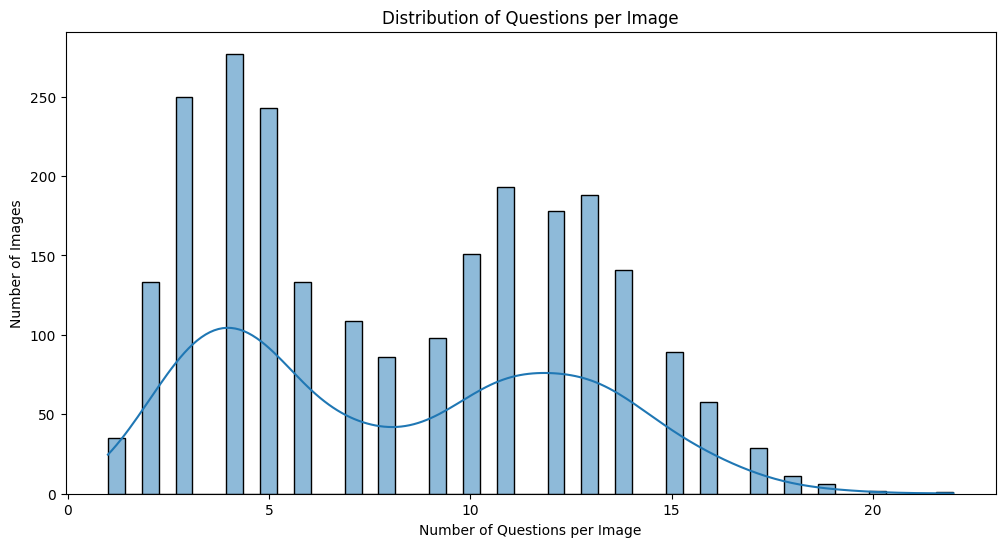

In [12]:
image_question_counts = data['image_id'].value_counts()

plt.figure(figsize=(12,6))
sns.histplot(image_question_counts, bins=50, kde=True)
plt.xlabel("Number of Questions per Image")
plt.ylabel("Number of Images")
plt.title("Distribution of Questions per Image")
plt.show()


In [13]:
yes_no_answers = ["yes", "no"]
color_answers = ["red", "blue", "green", "yellow", "black", "white", "orange", "purple", "pink", "brown", "grey"]
position_answers = ["left", "right", 'above', 'below', 'front', 'behind']
numeric_answers = data['answer'].apply(lambda x: str(x).isdigit()) 

In [14]:
color_answers_dis = {
    "Red": data[data['answer'].str.lower().isin(["red"])].shape[0],
    "Blue": data[data['answer'].str.lower().isin(["blue"])].shape[0],
    "Green": data[data['answer'].str.lower().isin(["green"])].shape[0], 
    "Yellow": data[data['answer'].str.lower().isin(["yellow"])].shape[0],
    "Black": data[data['answer'].str.lower().isin(["black"])].shape[0],
    "White": data[data['answer'].str.lower().isin(["white"])].shape[0], 
    "Orange": data[data['answer'].str.lower().isin(["orange"])].shape[0],
    "Purple": data[data['answer'].str.lower().isin(["purple"])].shape[0],   
    "Pink": data[data['answer'].str.lower().isin(["pink"])].shape[0],
    "Brown": data[data['answer'].str.lower().isin(["brown"])].shape[0],
    "Grey": data[data['answer'].str.lower().isin(["grey"])].shape[0]
    }

color_distribution = pd.DataFrame(list(color_answers_dis.items()), columns=['Color', 'Count'])

In [15]:
color_distribution

,Color,Count
0,Red,410
1,Blue,343
2,Green,326
3,Yellow,212
4,Black,430
5,White,507
6,Orange,160
7,Purple,37
8,Pink,136
9,Brown,402


C:\Users\DELL\AppData\Local\Temp\ipykernel_23404\1052665799.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=color_distribution["Color"], y=color_distribution["Count"], palette="tab10")


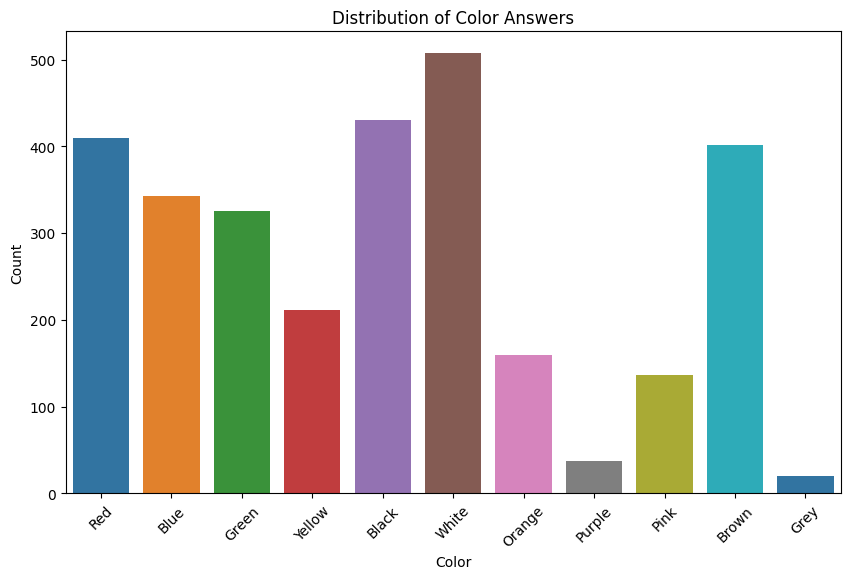

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(x=color_distribution["Color"], y=color_distribution["Count"], palette="tab10")
plt.xlabel("Color")
plt.ylabel("Count")
plt.title("Distribution of Color Answers")
plt.xticks(rotation=45)
plt.show()

In [17]:
position_answers_dis = {
    "Left": data[data['answer'].str.lower().isin(["left"])].shape[0],
    "Right": data[data['answer'].str.lower().isin(["right"])].shape[0],
    "Above": data[data['answer'].str.lower().isin(["above"])].shape[0],
    "Below": data[data['answer'].str.lower().isin(["below"])].shape[0],
    "Front": data[data['answer'].str.lower().isin(["front"])].shape[0],
    "Behind": data[data['answer'].str.lower().isin(["behind"])].shape[0]
    }

position_distribution = pd.DataFrame(list(position_answers_dis.items()), columns=['Position', 'Count'])

In [18]:
position_distribution

,Position,Count
0,Left,380
1,Right,308
2,Above,354
3,Below,153
4,Front,195
5,Behind,257


C:\Users\DELL\AppData\Local\Temp\ipykernel_23404\3359056858.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=position_distribution["Position"], y=position_distribution["Count"], palette="tab10")


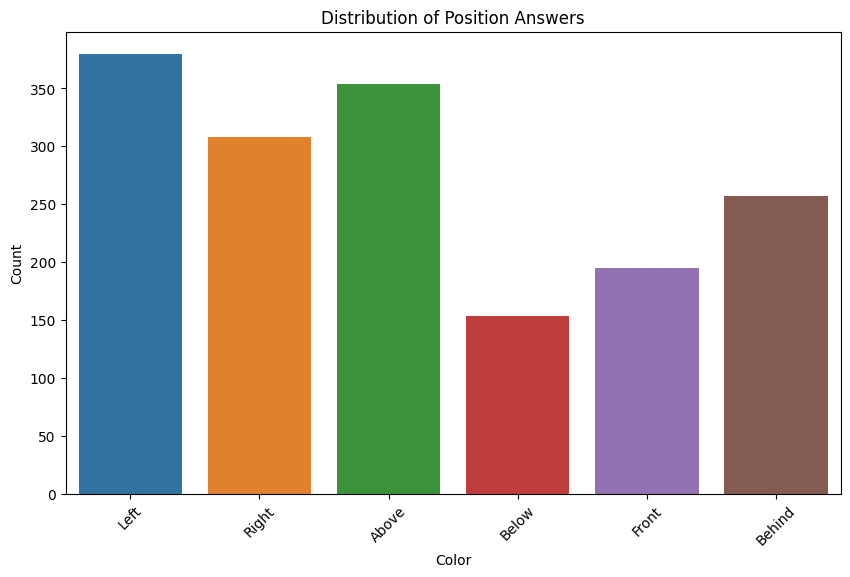

In [19]:
plt.figure(figsize=(10, 6))
sns.barplot(x=position_distribution["Position"], y=position_distribution["Count"], palette="tab10")
plt.xlabel("Color")
plt.ylabel("Count")
plt.title("Distribution of Position Answers")
plt.xticks(rotation=45)
plt.show()

In [20]:
answer_types = {
    "Yes/No": data[data['answer'].str.lower().isin(yes_no_answers)].shape[0],
    "Color": data[data['answer'].str.lower().isin(color_answers)].shape[0],
    "Position": data[data['answer'].str.lower().isin(position_answers)].shape[0],
    "Numeric": numeric_answers.sum(),
    "Object": data.shape[0] - (numeric_answers.sum() +
                            data[data['answer'].str.lower().isin(yes_no_answers)].shape[0] +
                            data[data['answer'].str.lower().isin(color_answers)].shape[0] +
                            data[data['answer'].str.lower().isin(position_answers)].shape[0])
}
answer_distribution = pd.DataFrame(list(answer_types.items()), columns=['Answer Type', 'Count'])

In [21]:
answer_distribution

,Answer Type,Count
0,Yes/No,12601
1,Color,2983
2,Position,1647
3,Numeric,1751
4,Object,840


C:\Users\DELL\AppData\Local\Temp\ipykernel_23404\101202989.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=answer_distribution["Answer Type"], y=answer_distribution["Count"], palette="tab10")


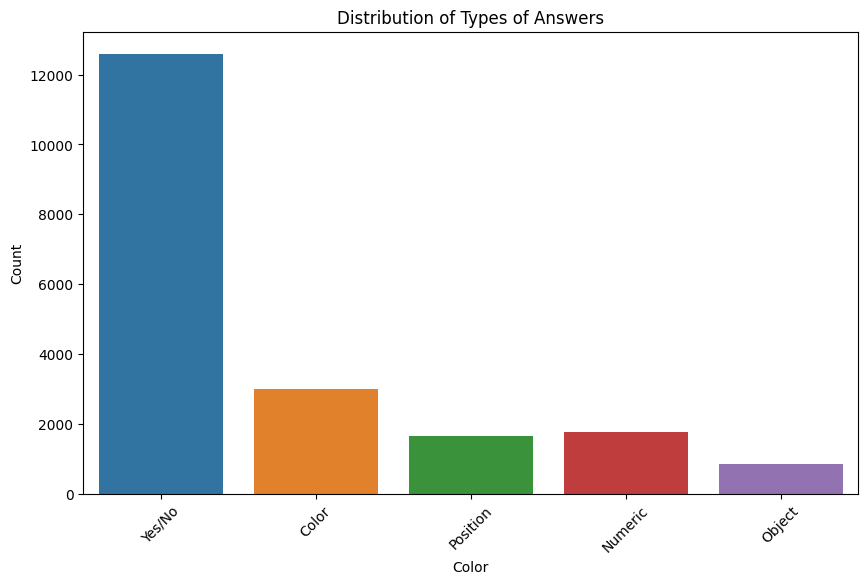

In [22]:
plt.figure(figsize=(10, 6))
sns.barplot(x=answer_distribution["Answer Type"], y=answer_distribution["Count"], palette="tab10")
plt.xlabel("Color")
plt.ylabel("Count")
plt.title("Distribution of Types of Answers")
plt.xticks(rotation=45)
plt.show()

In [24]:
object_answers = data[~data['answer'].str.lower().isin(yes_no_answers) &
                   ~data['answer'].str.lower().isin(color_answers) &
                   ~data['answer'].str.lower().isin(position_answers) &
                   ~numeric_answers]

top_objects = object_answers['answer'].value_counts().head(20)

object_distribution = pd.DataFrame(top_objects).reset_index()
object_distribution.columns = ['Object Name', 'Count']

object_distribution

,Object Name,Count
0,person,148
1,bird,61
2,dog,52
3,cat,44
4,vase,36
5,bowl,36
6,boat,36
7,scissors,30
8,airplane,28
9,teddy bear,28


C:\Users\DELL\AppData\Local\Temp\ipykernel_23404\511891536.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=numeric_answers, y=position_distribution["Count"], palette="tab10")


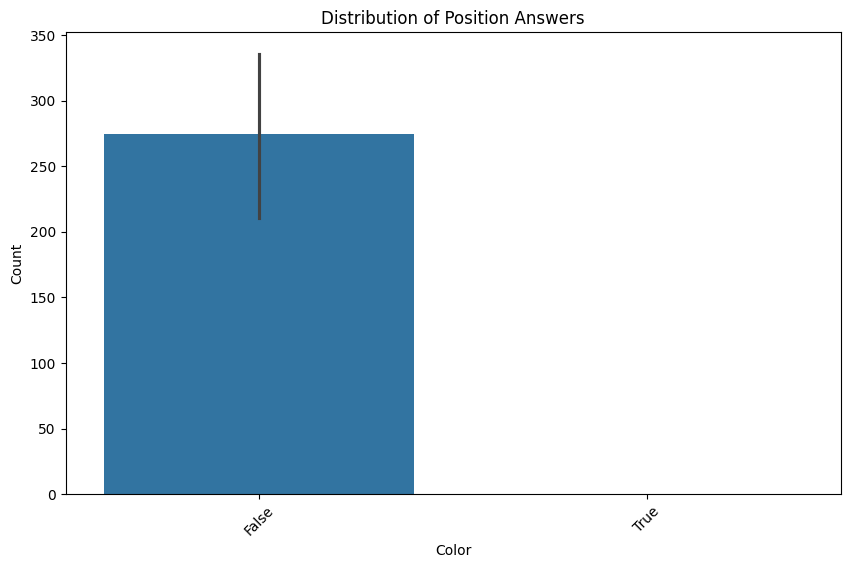

In [25]:
plt.figure(figsize=(10, 6))
sns.barplot(x=numeric_answers, y=position_distribution["Count"], palette="tab10")
plt.xlabel("Color")
plt.ylabel("Count")
plt.title("Distribution of Position Answers")
plt.xticks(rotation=45)
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_23404\484397499.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=object_distribution["Object Name"], y=object_distribution["Count"], palette="tab10")


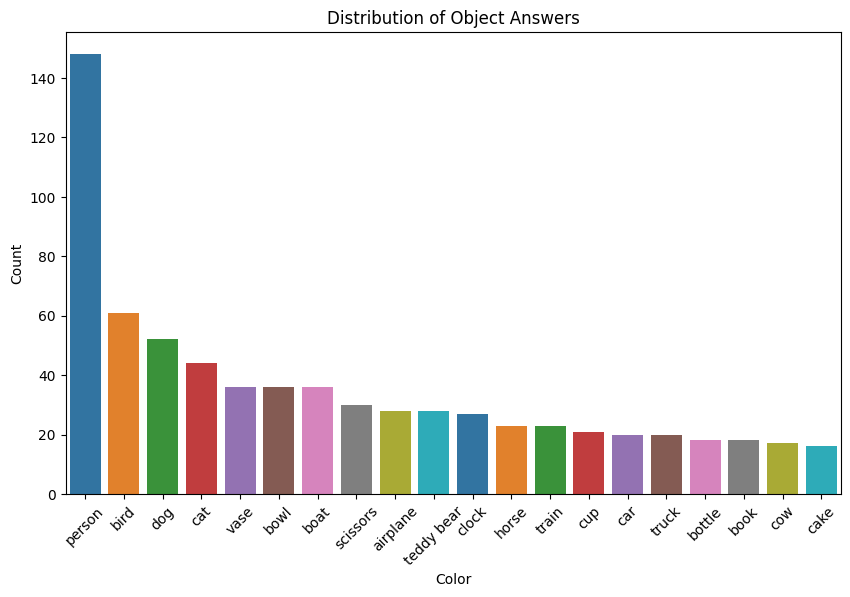

In [26]:
plt.figure(figsize=(10, 6))
sns.barplot(x=object_distribution["Object Name"], y=object_distribution["Count"], palette="tab10")
plt.xlabel("Color")
plt.ylabel("Count")
plt.title("Distribution of Object Answers")
plt.xticks(rotation=45)
plt.show()

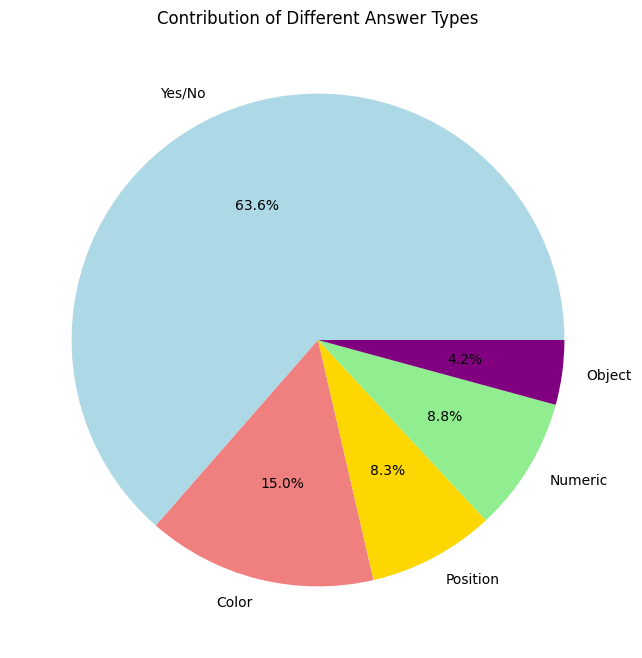

In [27]:
plt.figure(figsize=(8, 8))
plt.pie(answer_types.values(), labels=answer_types.keys(), autopct='%1.1f%%', colors=['lightblue', 'lightcoral', 'gold', 'lightgreen', 'purple'])
plt.title("Contribution of Different Answer Types")
plt.show()

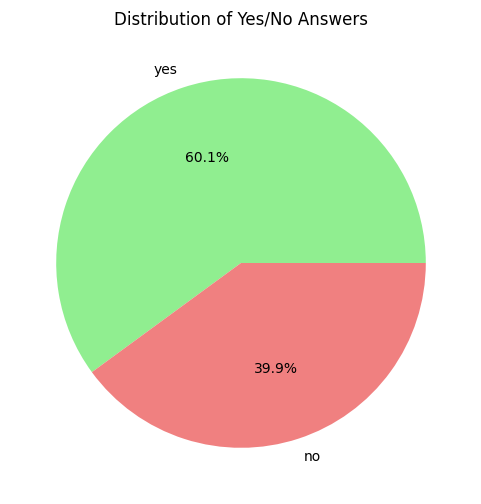

In [28]:
yes_no_counts = data[data['answer'].str.lower().isin(yes_no_answers)]['answer'].str.lower().value_counts()

plt.figure(figsize=(6, 6))
plt.pie(yes_no_counts, labels=yes_no_counts.index, autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'])
plt.title("Distribution of Yes/No Answers")
plt.show()


In [29]:
yes_no_questions = data[data['answer'].str.lower().isin(yes_no_answers)]['question'].value_counts().head(10)
numeric_questions = data[numeric_answers]['question'].value_counts().head(10)
color_questions = data[data['answer'].str.lower().isin(color_answers)]['question'].value_counts().head(10)
position_questions = data[data['answer'].str.lower().isin(position_answers)]['question'].value_counts().head(10)

print("Top 10 Questions Leading to Yes/No Answers:\n", yes_no_questions)
print("\nTop 10 Questions Leading to Numeric Answers:\n", numeric_questions)
print("\nTop 10 Questions Leading to Color Answers:\n", color_questions)
print("\nTop 10 Questions Leading to Position Answers:\n", position_questions)

Top 10 Questions Leading to Yes/No Answers:
 question
Are there any person in image?          811
Are there any cup in image?             249
Are there any bowl in image?            218
Are there any vase in image?            168
Are there any fork in image?            151
Are there any car in image?             147
Are there any teddy bear in image?      147
Are there any bottle in image?          145
Are there any dining table in image?    141
Are there any knife in image?           141
Name: count, dtype: int64

Top 10 Questions Leading to Numeric Answers:
 question
How many person in image?        435
How many cup in image?            75
How many bowl in image?           67
How many car in image?            51
How many wine glass in image?     43
How many chair in image?          38
How many bottle in image?         37
How many cow in image?            37
How many vase in image?           36
How many orange in image?         31
Name: count, dtype: int64

Top 10 Questions Leading to

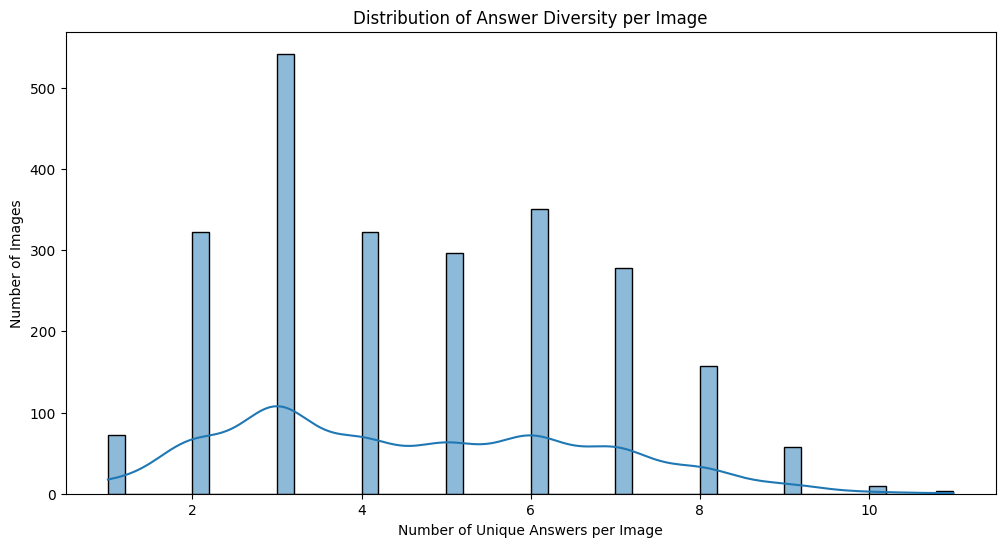

In [30]:
image_answer_counts = data.groupby('image_id')['answer'].nunique()

plt.figure(figsize=(12,6))
sns.histplot(image_answer_counts, bins=50, kde=True)
plt.xlabel("Number of Unique Answers per Image")
plt.ylabel("Number of Images")
plt.title("Distribution of Answer Diversity per Image")
plt.show()

In [31]:
data_copied = data.copy()

In [32]:
data_copied["question"] = data_copied["question"].astype(str).fillna("")
data_copied["question_lower"] = data_copied["question"].str.lower()

In [33]:
def classify_yes_no_question(question):
    if any(color in question for color in color_answers):
        return "Color-Related Yes/No"
    elif any(pos in question for pos in position_answers):
        return "Position-Related Yes/No"
    else:
        return "Object-Related Yes/No" 

C:\Users\DELL\AppData\Local\Temp\ipykernel_23404\4133553046.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=yes_no_distribution.index, y=yes_no_distribution.values, palette="coolwarm")


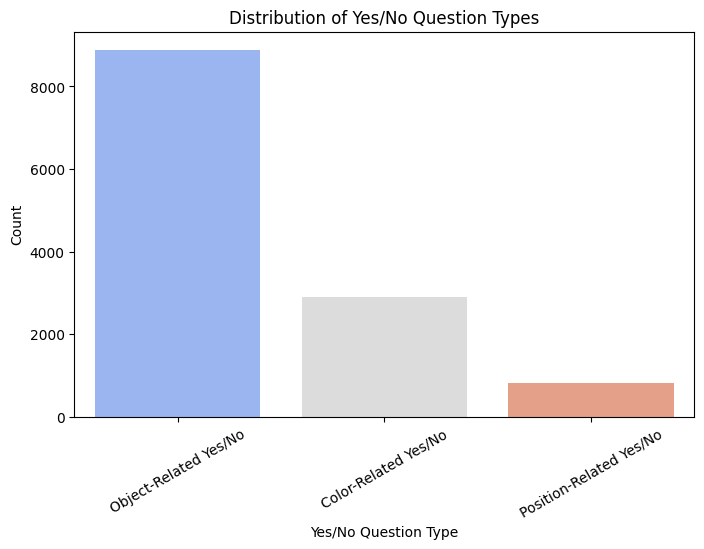

In [34]:
yes_no_questions = data_copied[data_copied["answer"].str.lower().isin(["yes", "no"])].copy()
yes_no_questions["Yes/No Category"] = yes_no_questions["question_lower"].apply(classify_yes_no_question)

yes_no_distribution = yes_no_questions["Yes/No Category"].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=yes_no_distribution.index, y=yes_no_distribution.values, palette="coolwarm")
plt.xlabel("Yes/No Question Type")
plt.ylabel("Count")
plt.title("Distribution of Yes/No Question Types")
plt.xticks(rotation=30)
plt.show()